In [1]:
import pandas as pd
import pymc as pm
import xarray as xr

from pymc_marketing.clv import ParetoNBDModel, plotting, utils

In [2]:
import pytensor

# set flag to fix open issue
pytensor.config.cxx = "/usr/bin/clang++"

Create a simple dataset for testing:

In [3]:
d = [
    [1, "2015-01-01", 1],
    [1, "2015-02-06", 2],
    [2, "2015-01-01", 2],
    [3, "2015-01-01", 3],
    [3, "2015-01-02", 1],
    [3, "2015-01-05", 5],
    [4, "2015-01-16", 6],
    [4, "2015-02-02", 3],
    [4, "2015-02-05", 3],
    [4, "2015-02-05", 2],
    [5, "2015-01-16", 3],
    [5, "2015-01-17", 1],
    [5, "2015-01-18", 8],
    [6, "2015-02-02", 5],
]
test_data = pd.DataFrame(d, columns=["id", "date", "monetary_value"])

Note customer 4 made two purchases on 2015-02-05. 

`_find_first_transactions` flags the first purchase each customer has made, which must be excluded for modeling. It is called internally by `rfm_summary`.

In [4]:
utils._find_first_transactions(
    transactions=test_data,
    customer_id_col="id",
    datetime_col="date",
    # monetary_value_col = "monetary_value",
    # datetime_format = "%Y%m%d",
).reindex()

,id,date,first
0,1,2015-01-01,True
1,1,2015-02-06,False
2,2,2015-01-01,True
3,3,2015-01-01,True
4,3,2015-01-02,False
5,3,2015-01-05,False
6,4,2015-01-16,True
7,4,2015-02-02,False
8,4,2015-02-05,False
10,5,2015-01-16,True


Notice how **9** is missing from the dataframe index. Multiple transactions in the same time period are treated as a single purchase, so the indices for those additional transactions are skipped. 

`rfm_summary` is the primary data preprocessing step for CLV modeling in the continuous, non-contractual domain:

In [5]:
rfm_df = utils.rfm_summary(
    test_data,
    customer_id_col="id",
    datetime_col="date",
    monetary_value_col="monetary_value",
    observation_period_end="2015-02-06",
    datetime_format="%Y-%m-%d",
    time_unit="W",
    include_first_transaction=True,
)

rfm_df.head()

,customer_id,frequency,recency,monetary_value
0,1,2.0,0.0,1.5
1,2,1.0,5.0,2.0
2,3,2.0,4.0,4.5
3,4,2.0,0.0,7.0
4,5,1.0,3.0,12.0


For MAP fits and covariate models, `rfm_train_test_split` can be used to evaluate models on unseen data. It is also useful for identifying the impact of a time-based event like a marketing campaign.

In [6]:
train_test = utils.rfm_train_test_split(
    test_data,
    customer_id_col="id",
    datetime_col="date",
    train_period_end="2015-02-01",
    monetary_value_col="monetary_value",
)

train_test.head()

,customer_id,frequency,recency,T,monetary_value,test_frequency,test_monetary_value,test_T
0,1,0.0,0.0,31.0,0.0,1.0,2.0,5.0
1,2,0.0,0.0,31.0,0.0,0.0,0.0,5.0
2,3,2.0,4.0,31.0,3.0,0.0,0.0,5.0
3,4,0.0,0.0,16.0,0.0,2.0,4.0,5.0
4,5,2.0,2.0,16.0,4.5,0.0,0.0,5.0


`rfm_segments` will assign customer to segments based on their recency, frequency, and monetary value. It uses a quartile-based RFM score approach that is very computationally efficient, but defining custom segments is a rather subjective exercise. The returned dataframe also cannot be used for modeling because it does not zero out the initial transactions.

In [7]:
segments = utils.rfm_segments(
    test_data,
    customer_id_col="id",
    datetime_col="date",
    monetary_value_col="monetary_value",
    observation_period_end="2015-02-06",
    datetime_format="%Y-%m-%d",
    time_unit="W",
)

/Users/coltallen/Projects/pymc-marketing/pymc_marketing/clv/utils.py:720: UserWarning: RFM score will not exceed 2 for f_quartile. Specify a custom segment_config
  warnings.warn(


# Plotting
`expected_cumulative_transactions` and all other plotting functions require a fitted model. Test with both MAP and full posteriors:

In [8]:
url_cdnow = "https://raw.githubusercontent.com/pymc-labs/pymc-marketing/main/data/cdnow_transactions.csv"
raw_trans = pd.read_csv(url_cdnow)

rfm_data = utils.rfm_summary(
    raw_trans,
    customer_id_col="id",
    datetime_col="date",
    datetime_format="%Y%m%d",
    time_unit="W",
    observation_period_end="19970930",
    # time_scaler = 7,
)

rfm_train_test = utils.rfm_train_test_split(
    raw_trans,
    customer_id_col="id",
    datetime_col="date",
    train_period_end="19970701",
    datetime_format="%Y%m%d",
    time_unit="W",
    test_period_end="19970930",
)

t = rfm_data["T"].max().astype(int)
t_start_eval = rfm_train_test["T"].max()

pnbd_split = ParetoNBDModel()
pnbd_split.fit(data=rfm_data)

Output()

<xarray.DataTree>
Group: /
│   Attributes:
│       id:              1960ad0ac50a5b08
│       model_type:      Pareto/NBD
│       version:         None
│       sampler_config:  {}
│       model_config:    {"r": {"dist": "Weibull", "kwargs": {"alpha": 2, "beta":...
├── Group: /posterior
│       Dimensions:  (chain: 1, draw: 1)
│       Coordinates:
│         * chain    (chain) int64 8B 0
│         * draw     (draw) int64 8B 0
│       Data variables:
│           alpha    (chain, draw) float64 8B 14.46
│           beta     (chain, draw) float64 8B 10.48
│           r        (chain, draw) float64 8B 0.6338
│           s        (chain, draw) float64 8B 0.4882
│       Attributes:
│           created_at:                 2026-09-01T05:53:02.069734+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           pymc_marketing_version:     1.1.0
├── Group: /sample_stats
│       Attributes:
│           created_at:                 2026-09-01T05:53:02.070673+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:            (customer_id: 2357, obs_var: 2)
│       Coordinates:
│         * customer_id        (customer_id) int64 19kB 1 2 3 4 ... 2354 2355 2356 2357
│         * obs_var            (obs_var) <U9 72B 'recency' 'frequency'
│       Data variables:
│           recency_frequency  (customer_id, obs_var) float64 38kB 30.0 2.0 ... 0.0 0.0
│       Attributes:
│           created_at:                 2026-09-01T05:53:02.071430+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                []
└── Group: /fit_data
        Dimensions:      (index: 2357)
        Coordinates:
          * index        (index) int64 19kB 0 1 2 3 4 5 ... 2352 2353 2354 2355 2356
        Data variables:
            customer_id  (index) int64 19kB 1 2 3 4 5 6 ... 2353 2354 2355 2356 2357
            frequency    (index) float64 19kB 2.0 1.0 0.0 0.0 0.0 ... 5.0 0.0 4.0 0.0
            recency      (index) float64 19kB 30.0 2.0 0.0 0.0 0.0 ... 24.0 0.0 26.0 0.0
            T            (index) float64 19kB 39.0 39.0 39.0 39.0 ... 27.0 27.0 27.0

### Cohort Retention

`plot_cohorts` describes the observed data only — no model is fitted or consulted, so it
accepts the data shapes used by every CLV transaction model. Pass `datetime_col` to read a
raw transaction log, and cohorts are built from each customer's first purchase period:

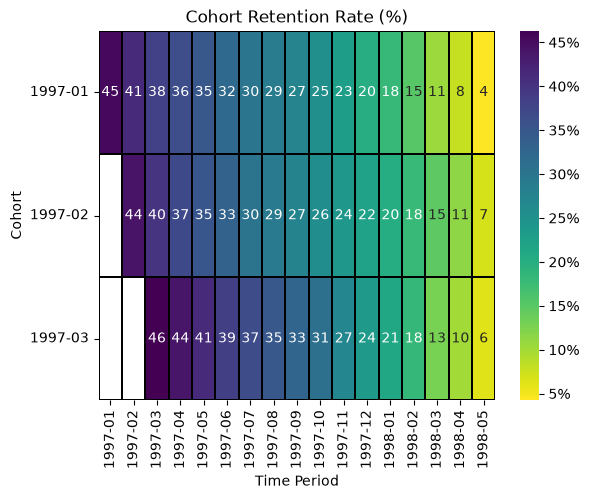

In [9]:
plotting.plot_cohorts(
    raw_trans,
    customer_id_col="id",
    datetime_col="date",
    datetime_format="%Y%m%d",
    time_unit="M",
    show_pct=True,
);

Summary data works too. When there is no `cohort` column the acquisition cohort is recovered
from `T`, since a larger `T` implies an earlier acquisition. Cohort labels that are not dates —
such as the segment labels used by `ShiftedBetaGeoModel` — fall back to a cohort-age axis:

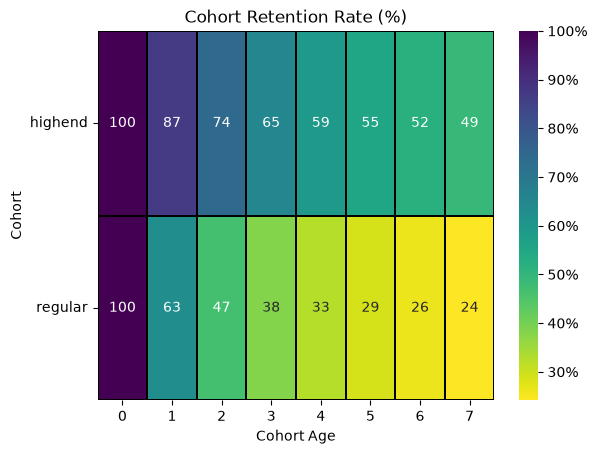

In [10]:
sbg_data = pd.read_csv(
    "https://raw.githubusercontent.com/pymc-labs/pymc-marketing/main/data/sbg_cohorts.csv"
)

plotting.plot_cohorts(sbg_data, show_pct=True);

### Expected Cumulative Purchases

In [11]:
df_cum = utils._expected_cumulative_transactions(
    model=pnbd_split,
    transactions=raw_trans,
    customer_id_col="id",
    datetime_col="date",
    t=t,
    datetime_format="%Y%m%d",
    time_unit="W",
    set_index_date=True,
)

# `predicted` keeps the chain/draw dims, so uncertainty can be summarized downstream
df_cum

<xarray.Dataset> Size: 952B
Dimensions:    (period: 39, chain: 1, draw: 1)
Coordinates:
  * period     (period) datetime64[ns] 312B 1996-12-30 1997-01-06 ... 1997-09-22
  * chain      (chain) int64 8B 0
  * draw       (draw) int64 8B 0
Data variables:
    actual     (period) int64 312B 0 3 17 44 67 122 ... 2002 2051 2094 2141 2195
    predicted  (chain, draw, period) float64 312B 4.286 15.6 ... 2.263e+03

If doing a train/test split, or studying time interventions like marketing campaigns, `plot_expected_purchases_over_time` can be used for easy visual interpretation.

`pnbd_split` above was fit with `.fit()`, which defaults to MAP and yields a posterior holding a single draw. An HDI band would have zero width there, so it is omitted; see further down for the band on a sampled fit.

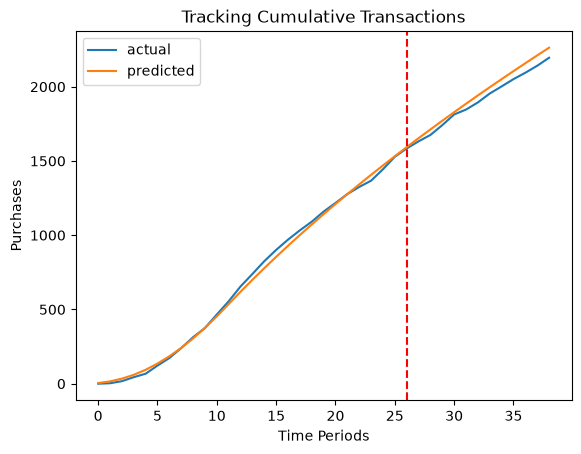

In [12]:
plotting.plot_expected_purchases_over_time(
    model=pnbd_split,
    purchase_history=raw_trans,
    customer_id_col="id",
    datetime_col="date",
    t=t,
    t_start_eval=t_start_eval,
    datetime_format="%Y%m%d",
    time_unit="W",
    plot_cumulative=True,
);

/Users/coltallen/Projects/pymc-marketing/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run pareto_nbd_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [alpha, beta, r, recency_frequency, s]


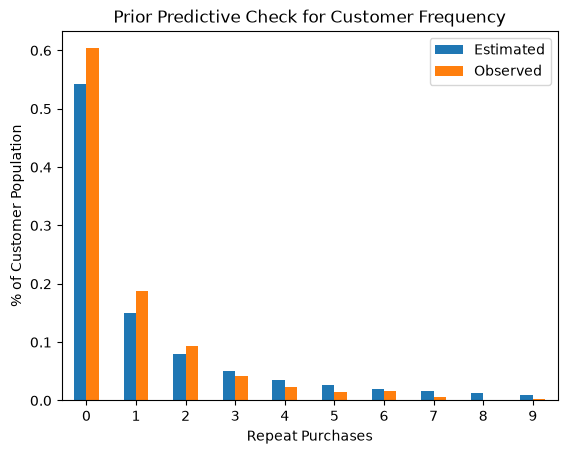

In [13]:
plotting.plot_expected_purchases_ppc(pnbd_split, ppc="prior");

/Users/coltallen/Projects/pymc-marketing/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run pareto_nbd_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [recency_frequency]


Output()

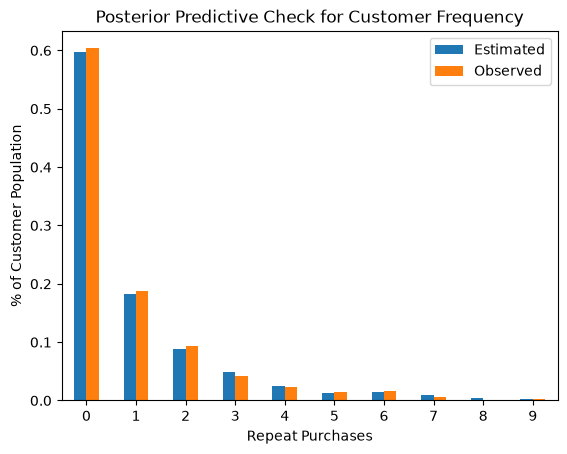

In [14]:
from matplotlib import pyplot as plt

fig = plt.figure()

fig.add_axes(plotting.plot_expected_purchases_ppc(pnbd_split, ppc="posterior"))

fig.savefig("save_test.png");

Now fit a model by sampling from the posterior distributions:

In [15]:
pnbd = ParetoNBDModel()

pnbd.build_model(data=rfm_data)
with pnbd.model:
    pnbd.idata = pm.sample(
        step=pm.DEMetropolisZ(),
        tune=2500,
        draws=3000,
        idata_kwargs={"log_likelihood": True},
    )

Multiprocess sampling (4 chains in 4 jobs)


DEMetropolisZ: [alpha, beta, r, s]


Output()

/Users/coltallen/Projects/pymc-marketing/.venv/lib/python3.12/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 2_500 tune and 3_000 draw iterations (10_000 + 12_000 draws total) took 5 seconds.


In [16]:
pnbd.fit_summary()

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,14.63,1.11,13,16,996,1288,1.00,0.035,0.024
beta,12.5,4,6.8,19,773,1103,1.01,0.14,0.1
r,0.64,0.053,0.56,0.73,967,1389,1.00,0.0017,0.0012
s,0.543,0.107,0.39,0.73,738,1102,1.01,0.0039,0.0028


In [17]:
# thin_fit_result is not supported with external sampler fits in `ParetoNBDModel`!
# pnbd.idata = pnbd.thin_fit_result(keep_every=3)

pnbd.idata = pnbd.idata.isel(draw=slice(None, None, 3)).copy()
pnbd.idata

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 1000)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 3 6 9 12 15 18 ... 2982 2985 2988 2991 2994 2997
│       Data variables:
│           alpha    (chain, draw) float64 32kB 14.5 14.5 14.5 ... 15.38 15.38 16.05
│           beta     (chain, draw) float64 32kB 10.55 10.55 10.55 ... 14.07 14.07 13.62
│           r        (chain, draw) float64 32kB 0.6636 0.6636 0.6639 ... 0.6537 0.6987
│           s        (chain, draw) float64 32kB 0.5116 0.5116 0.5116 ... 0.6423 0.5956
│       Attributes:
│           created_at:                 2026-09-01T05:53:15.246490+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              5.11139702796936
│           tuning_steps:               2500
├── Group: /sample_stats
│       Dimensions:   (chain: 4, draw: 1000)
│       Coordinates:
│         * chain     (chain) int64 32B 0 1 2 3
│         * draw      (draw) int64 8kB 0 3 6 9 12 15 ... 2982 2985 2988 2991 2994 2997
│       Data variables:
│           accepted  (chain, draw) bool 4kB False False False ... False False False
│           lambda    (chain, draw) float64 32kB 0.8415 0.8415 0.8415 ... 0.8415 0.8415
│           scaling   (chain, draw) float64 32kB 0.0003452 0.0003452 ... 0.0002796
│           accept    (chain, draw) float64 32kB 0.06158 0.03393 ... 0.0001917 0.04552
│       Attributes:
│           created_at:                 2026-09-01T05:53:15.248665+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              5.11139702796936
│           tuning_steps:               2500
├── Group: /observed_data
│       Dimensions:            (customer_id: 2357, obs_var: 2)
│       Coordinates:
│         * customer_id        (customer_id) int64 19kB 1 2 3 4 ... 2354 2355 2356 2357
│         * obs_var            (obs_var) <U9 72B 'recency' 'frequency'
│       Data variables:
│           recency_frequency  (customer_id, obs_var) float64 38kB 30.0 2.0 ... 0.0 0.0
│       Attributes:
│           created_at:                 2026-09-01T05:53:15.249770+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                []
└── Group: /log_likelihood
        Dimensions:            (chain: 4, draw: 1000, customer_id: 2357)
        Coordinates:
          * chain              (chain) int64 32B 0 1 2 3
          * draw               (draw) int64 8kB 0 3 6 9 12 ... 2985 2988 2991 2994 2997
          * customer_id        (customer_id) int64 19kB 1 2 3 4 ... 2354 2355 2356 2357
        Data variables:
            recency_frequency  (chain, draw, customer_id) float64 75MB -9.387 ... -0....
        Attributes:
            created_at:                 2026-09-01T05:53:19.846546+00:00
            creation_library:           ArviZ
            creation_library_version:   1.2.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  6.2.0
            sample_dims:                ['chain', 'draw']

With a sampled posterior the `hdi_prob` argument shades a credible interval around the predicted line. The band is computed on the posterior itself, so for `plot_cumulative=False` it is an interval on the incremental quantity rather than a differenced pair of cumulative bounds.

Passing a sequence nests several bands. They are drawn widest first, so the overlapping fills leave the narrower interval more opaque.

`pnbd` was fit on data truncated at 1997-09-30, so the dashed line marks where the in-sample period ends and the forecast begins. Note how the bands widen beyond it.

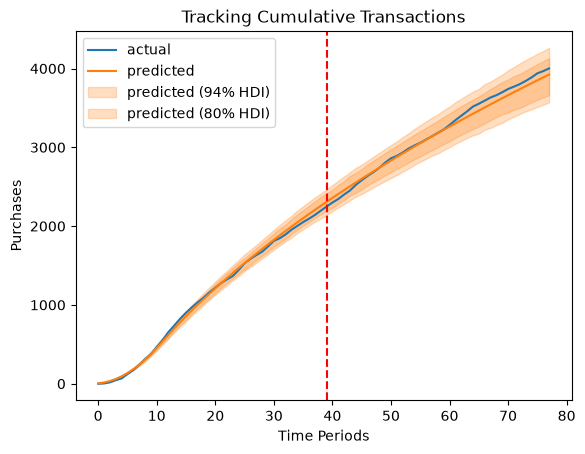

In [18]:
# The observed series only extends as far as the data does, so asking for more periods
# than `raw_trans` covers flattens it. `t = 25 * 7` is the daily idiom, for time_unit="D"
# with time_scaler=7; in weeks the data covers 78 periods.
t_full = (
    pd.to_datetime(raw_trans["date"], format="%Y%m%d")
    .dt.to_period("W")
    .pipe(lambda s: (s.max() - s.min()).n)
)

plotting.plot_expected_purchases_over_time(
    model=pnbd,
    purchase_history=raw_trans,
    customer_id_col="id",
    datetime_col="date",
    t=t_full,
    t_start_eval=t,
    datetime_format="%Y%m%d",
    time_unit="W",
    plot_cumulative=True,
    hdi_prob=[0.8, 0.94],
);

/Users/coltallen/Projects/pymc-marketing/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run pareto_nbd_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [alpha, beta, r, recency_frequency, s]


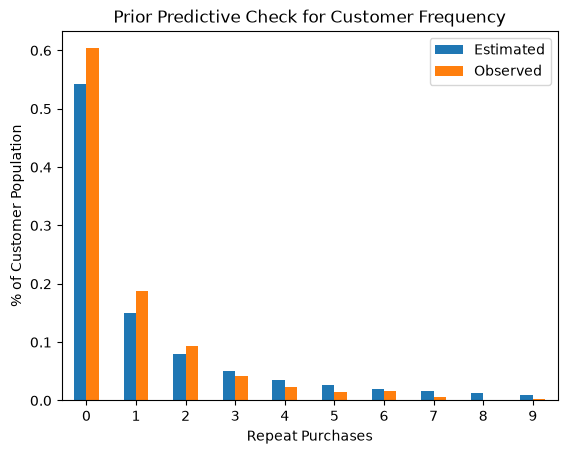

In [19]:
plotting.plot_expected_purchases_ppc(pnbd, ppc="prior");

/Users/coltallen/Projects/pymc-marketing/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run pareto_nbd_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [recency_frequency]


Output()

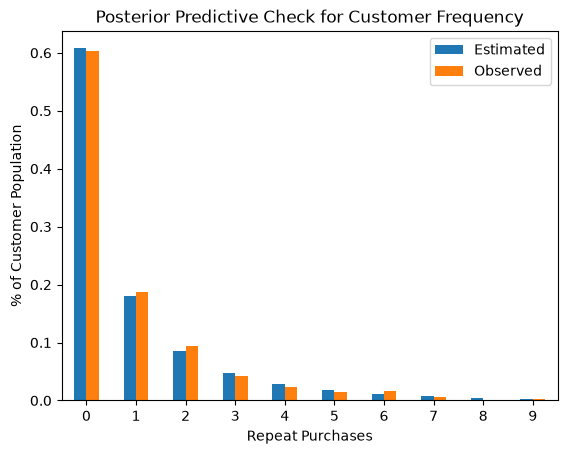

In [20]:
plotting.plot_expected_purchases_ppc(pnbd, ppc="posterior");

Adding HDIs to `plot_purchase_pmf` requires value counts to be grouped coordinate-wise across a dimension like `draws`, which may not be supported in `xarray`. `arviz.hdi` can then be applied across all value counts for interval estimation.

In [21]:
# keep n_samples=1
pnbd.distribution_new_customer_recency_frequency(
    random_seed=45,
    n_samples=1,
).sel(obs_var="frequency")

/Users/coltallen/Projects/pymc-marketing/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run pareto_nbd_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [recency_frequency]


Output()

<xarray.DataArray 'recency_frequency' (chain: 4, draw: 1000, customer_id: 2357)> Size: 75MB
array([[[ 1.,  4.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  2.,  0.,  0.],
        [ 1.,  0.,  6., ...,  1.,  2.,  8.],
        ...,
        [ 0.,  0.,  1., ...,  2.,  0.,  2.],
        [ 1.,  2.,  0., ...,  0.,  4.,  0.],
        [ 1.,  0.,  0., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  5., ...,  0.,  1.,  3.],
        [ 0.,  0.,  1., ...,  0.,  4.,  2.],
        [ 0.,  0.,  0., ...,  0.,  1.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 1.,  0.,  2., ...,  1.,  0.,  2.],
        [ 1.,  0.,  4., ...,  4.,  1.,  2.]],

       [[ 0., 10.,  4., ...,  1.,  1.,  0.],
        [ 0.,  6.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  3., ...,  1.,  0.,  2.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  4.,  1.],
        [ 0.,  2.,  0., ...,  0.,  0.,  0.],
        [ 7.,  1.,  0., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  1., ...,  1.,  0.,  0.],
        [ 3.,  1.,  5., ...,  0.,  0.,  2.],
        [ 0.,  3., 10., ...,  3.,  0.,  2.],
        ...,
        [ 1.,  0.,  0., ...,  3.,  0.,  0.],
        [ 1.,  0.,  1., ...,  0.,  0.,  1.],
        [ 0.,  0.,  5., ...,  0.,  1.,  0.]]], shape=(4, 1000, 2357))
Coordinates:
  * chain        (chain) int64 32B 0 1 2 3
  * draw         (draw) int64 8kB 0 3 6 9 12 15 ... 2985 2988 2991 2994 2997
  * customer_id  (customer_id) int64 19kB 1 2 3 4 5 ... 2353 2354 2355 2356 2357
    obs_var      <U9 36B 'frequency'

In [22]:
import pymc as pm

# TODO: Add build_model() before a prior predictive check
pnbd.build_model(data=rfm_data)
with pnbd.model:
    prior_idata = pm.sample_prior_predictive(random_seed=45, draws=100)

# obs_var must be obtained from  prior_idata in case of an unfit model
obs_freq = prior_idata.observed_data["recency_frequency"].sel(obs_var="frequency")
ppc_freq = prior_idata.prior_predictive["recency_frequency"].sel(
    obs_var="frequency"
)  # .mean(("chain","draw"))
# ppc_freq = prior_idata.prior_predictive["recency_frequency"].sel(obs_var="frequency").mean(("chain","draw"))#.rename({o

ppc_df = (
    ppc_freq.to_dataframe()["recency_frequency"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

# Percentages are the only way to compare actual counts to chain*draw simulated counts
# merged_xr.to_dataframe()["recency_frequency"].value_counts(normalize=True) * 100
# merged_xr.to_dataframe()["ppc_mean"].value_counts(normalize=True) * 100

/Users/coltallen/Projects/pymc-marketing/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run pareto_nbd_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [alpha, beta, r, recency_frequency, s]


<Axes: >

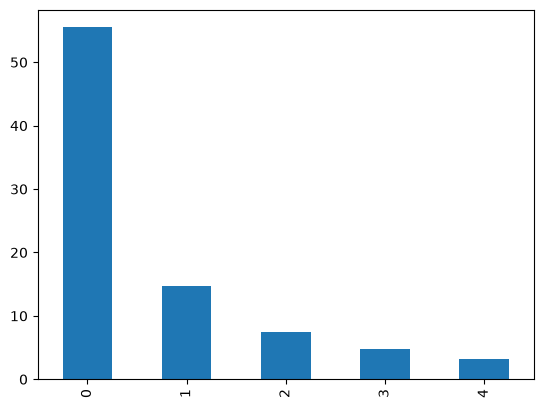

In [23]:
ppc_df.reset_index()["proportion"].head(5).plot(kind="bar")

In [24]:
# This will do value counts for entire DataArray
# ppc_freq.groupby(ppc_freq).count()
# ppc_freq.groupby(chain=UniqueGrouper()).count()

# value_counts = xr.DataArray(np.bincount(ppc_freq.values), dims="value")
# np.bincount(ppc_freq.values)
xr.DataArray([1, 2, 2, 3, 3, 3], dims="x")
# but what about individual customers?
# create a value count coordinate
# prior_idata.prior_predictive.coords["value_counts"] = ppc_freq.groupby(ppc_freq).count()["ppc_mean"].values
# ppc_freq = prior_idata.rename_vars({"recency_frequency":"ppc_mean"}).prior_predictive["ppc_mean"]#.sel(obs_var="frequency")#.mean(("chain","draw"))
# ppc_freq
# prior_idata.prior_predictive.groupby(value_counts=UniqueGrouper()).count().sel(obs_var="frequency")
# prior_idata.prior_predictive.groupby("customer_id").count()
# prior_idata#
#
# #ppc_freq.coords["grouped_customer"]
# ppc_freq.groupby(draw=UniqueGrouper()).count()

<xarray.DataArray (x: 6)> Size: 48B
array([1, 2, 2, 3, 3, 3])
Dimensions without coordinates: x

In [25]:
import arviz as az

# arviz 1.x: hdi() takes `data` positionally and returns a DataTree
calc_hdi = (
    az.hdi(
        prior_idata,
        prob=0.9,
        group="prior_predictive",
    )["/prior_predictive"]
    .to_dataset()
    .sel(obs_var="frequency")
)

hdi_lo = calc_hdi.sel(ci_bound="lower").to_array().squeeze()
hdi_hi = calc_hdi.sel(ci_bound="upper").to_array().squeeze()

# TODO: Join back to ppc_freq & obs var
hdi_hi

<xarray.DataArray (customer_id: 2357)> Size: 19kB
array([ 6., 11.,  7., ...,  4.,  6.,  7.], shape=(2357,))
Coordinates:
  * customer_id  (customer_id) int64 19kB 1 2 3 4 5 ... 2353 2354 2355 2356 2357
    obs_var      <U9 36B 'frequency'
    ci_bound     <U5 20B 'upper'
    variable     <U17 68B 'recency_frequency'